# Modelo binario — ¿quién gana la contienda?

Primer modelo: dado el conjunto de candidatos de un municipio, predecir **cuál gana**.

**Encuadre correcto.** No es una clasificación fila-a-fila suelta: exactamente *un* candidato
gana por contienda. Así que el modelo produce un **score por candidato** y la predicción es el
**argmax dentro de cada contienda**. Esto coincide con el "acierto del líder" del documento maestro.

**El listón a vencer.** El baseline ingenuo (gana el líder en dominancia de likes) ya acierta
**~71%** sobre 31 municipios. El modelo solo es útil si supera eso de forma estable.

**Validación honesta.** Con datos agrupados por contienda (comparten denominador), la validación
es **leave-one-contest-out** (`LeaveOneGroupOut` por DIVIPOLA). Partir candidatos de la misma
contienda entre train y test sería fuga de información.

> ⚠️ **Advertencia de tamaño.** 31 contiendas / 120 candidatos es MUY poco. AutoML y, sobre todo,
> redes neuronales tienden a sobreajustar aquí. La estrategia ganadora suele ser la simplicidad
> regularizada. Construimos la red porque tiene valor compararla, pero con expectativas realistas.


---
## 0 — Datos y matriz de features

Cargamos como en el maestro y construimos una matriz **una fila = un candidato**, con las features
de cuota (composicionales, comparables dentro de la contienda) que el screening marcó como útiles.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import LeaveOneGroupOut

sns.set_theme(style="whitegrid"); pd.set_option("display.max_columns", None)
%matplotlib inline
AZUL_SABANA, ROJO, GRIS = "#1A2F6F", "#FF4B4B", "#A9A9A9"


In [2]:
# ---- Carga (idéntica al maestro) ----
base_path = os.getcwd()
excel_path = os.path.join(os.path.dirname(base_path), "Colombia", "Resultados electorales.xlsx")
csv_unificado  = os.path.join(base_path, "resultados", "redes_unificadas.csv")
csv_seguidores = os.path.join(base_path, "resultados", "seguidores.csv")

df_redes      = pd.read_csv(csv_unificado, sep=";", encoding="utf-8-sig")
df_electoral  = pd.read_excel(excel_path, sheet_name="Candidatos E-26 ALC").rename(columns={"ID Candidato": "id_candidato"})
df_seguidores = pd.read_csv(csv_seguidores, sep=";", encoding="utf-8-sig").fillna(0)
for ex in ["68547", "68081"]:
    df_redes = df_redes[~df_redes["id_candidato"].str.contains(ex, na=False)]

df_completo = df_redes.merge(df_seguidores[["id_candidato","tiktok_followers","twitter_followers","facebook_followers"]], on="id_candidato", how="left")
df_completo = df_completo.merge(df_electoral[["id_candidato","Candidato","Ganador","Votos"]], on="id_candidato", how="left")
df_completo["DIVIPOLA"] = df_completo["id_candidato"].astype(str).str.split("-").str[1].str.zfill(5)
TIPOS_TODOS = ["likes","comentarios","compartidos","favoritos","fb_haha","fb_care","fb_wow","fb_sad","fb_angry"]
cols_pres = [c for c in TIPOS_TODOS if c in df_completo.columns]
df_completo["interacciones_totales"] = df_completo[cols_pres].sum(axis=1)
print(f"Candidatos: {df_completo['id_candidato'].nunique()} | Municipios: {df_completo['DIVIPOLA'].nunique()}")


Candidatos: 120 | Municipios: 31


In [3]:
# ---- prepare_lens_data (del maestro, reducida a lo necesario) ----
FOLLOWER_COL = {"Facebook":"facebook_followers","Twitter":"twitter_followers","TikTok":"tiktok_followers"}

def prepare_lens_data(df, metric_col, lente="dominancia", platform=None):
    data = df.copy()
    if platform is not None:
        data = data[data["red_social"] == platform]
    if len(data) == 0 or metric_col not in data.columns:
        return pd.DataFrame()
    if platform is not None:
        data = data.assign(_seg=data[FOLLOWER_COL[platform]])
    else:
        data = data.assign(_seg=data[list(FOLLOWER_COL.values())].sum(axis=1))
    agg = data.groupby(["DIVIPOLA","id_candidato","Candidato","Ganador"]).agg(
        metric_sum=(metric_col,"sum"), n_posts=(metric_col,"count"),
        votos=("Votos","first"), seguidores=("_seg","first")).reset_index()
    if lente in ("totales","dominancia"):
        agg["valor_lente"] = agg["metric_sum"]
    elif lente == "por_post":
        agg["valor_lente"] = agg["metric_sum"]/agg["n_posts"].replace(0,np.nan)
    elif lente == "por_post_seg":
        agg["valor_lente"] = agg["metric_sum"]/(agg["n_posts"].replace(0,np.nan)*agg["seguidores"].replace(0,np.nan))
    agg = agg.replace([np.inf,-np.inf], np.nan)
    agg["pct_metric"] = (agg["valor_lente"]/agg.groupby("DIVIPOLA")["valor_lente"].transform("sum"))*100
    agg = agg[agg.groupby("DIVIPOLA")["valor_lente"].transform("sum") > 0]
    return agg


In [4]:
# ---- Matriz de features: una fila por candidato ----
# Elegidas por el screening del maestro: familia dominancia + por_post cross-platform.
# (Se EXCLUYE por_post_seg = ruido activo, y Twitter = datos faltantes + no mejora la cima.)
FEATURES = [
    ("likes",       "dominancia", None, "likes_dom"),
    ("comentarios", "dominancia", None, "coment_dom"),
    ("compartidos", "dominancia", None, "compart_dom"),
    ("likes",       "por_post",   None, "likes_pp"),
    ("comentarios", "por_post",   None, "coment_pp"),
    ("compartidos", "por_post",   None, "compart_pp"),
]

base = None
for tipo, lente, plat, nombre in FEATURES:
    d = prepare_lens_data(df_completo, tipo, lente, plat)[["id_candidato","DIVIPOLA","Ganador","pct_metric"]]
    d = d.rename(columns={"pct_metric": nombre})
    base = d if base is None else base.merge(d[["id_candidato", nombre]], on="id_candidato", how="left")

base["n_candidatos"] = base.groupby("DIVIPOLA")["id_candidato"].transform("count")
base["y"] = (base["Ganador"] == "Sí").astype(int)
base = base.dropna(subset=[f[3] for f in FEATURES]).reset_index(drop=True)

feat_cols = [f[3] for f in FEATURES] + ["n_candidatos"]
X = base[feat_cols].values
y = base["y"].values
groups = base["DIVIPOLA"].values
print(f"Filas: {len(base)} | Contiendas: {base['DIVIPOLA'].nunique()} | Ganadores: {y.sum()}")
print(f"Features: {feat_cols}")
base.head()


Filas: 120 | Contiendas: 31 | Ganadores: 31
Features: ['likes_dom', 'coment_dom', 'compart_dom', 'likes_pp', 'coment_pp', 'compart_pp', 'n_candidatos']


,id_candidato,DIVIPOLA,Ganador,likes_dom,coment_dom,compart_dom,likes_pp,coment_pp,compart_pp,n_candidatos,y
0,COL-05001-001,05001,Sí,61.082575,17.798919,56.042265,66.882005,17.165373,49.709993,6,1
1,COL-05001-004,05001,No,0.028290,0.033868,0.407573,0.336864,0.355199,3.931537,6,0
2,COL-05001-010,05001,No,24.042407,24.301482,5.241385,11.394442,10.144148,2.012321,6,0
3,COL-05001-011,05001,No,0.666633,1.420896,0.798842,0.561978,1.055025,0.545544,6,0
4,COL-05001-012,05001,No,13.605918,55.334904,36.600029,19.060318,68.276163,41.535532,6,0


---
## 1 — El marco de evaluación

Una función central: para cada contienda dejada afuera, el modelo da un score a sus candidatos y
predecimos al de score máximo. La métrica es el **% de contiendas donde acertamos al ganador**
(top-1), comparable directo con el baseline ingenuo.


In [5]:
def top1_logo(model, X, y, groups):
    '''Acierto top-1 por contienda con leave-one-contest-out.'''
    logo = LeaveOneGroupOut(); aciertos = total = 0
    for tr, te in logo.split(X, y, groups):
        m = clone(model).fit(X[tr], y[tr])
        score = m.predict_proba(X[te])[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X[te])
        aciertos += int(y[te][np.argmax(score)] == 1); total += 1
    return aciertos / total

def baseline_top1(col_idx, X, y, groups):
    '''Baseline ingenuo: gana el candidato con mayor valor en una sola feature.'''
    aciertos = total = 0
    for g in np.unique(groups):
        m = groups == g
        aciertos += int(y[m][np.argmax(X[m, col_idx])] == 1); total += 1
    return aciertos / total

bl = baseline_top1(feat_cols.index("likes_dom"), X, y, groups)
print(f"BASELINE ingenuo (líder en likes_dom gana): {bl:.1%}  <- el listón a vencer")


BASELINE ingenuo (líder en likes_dom gana): 71.0%  <- el listón a vencer


---
## 2 — Bake-off de modelos (el "AutoML" honesto para datos chicos)

Comparamos varios modelos bajo **la misma** validación leave-one-contest-out. En datos de este
tamaño, un bake-off controlado es más honesto que un AutoML de caja negra (que sobreajusta la
selección). Incluimos una red neuronal pequeña.


In [6]:
modelos = {
    "Regresión logística (L2)": Pipeline([("sc", StandardScaler()),
        ("lr", LogisticRegression(C=0.5, max_iter=2000))]),
    "Random Forest":            RandomForestClassifier(n_estimators=300, max_depth=4,
                                    min_samples_leaf=5, random_state=0),
    "Gradient Boosting":        HistGradientBoostingClassifier(max_depth=3, max_iter=200,
                                    learning_rate=0.05, random_state=0),
    "Red neuronal (MLP 8)":     Pipeline([("sc", StandardScaler()),
        ("nn", MLPClassifier(hidden_layer_sizes=(8,), alpha=1.0, max_iter=2000,
                             early_stopping=True, random_state=0))]),
}

filas = [{"modelo": "BASELINE (líder likes_dom)", "top1_acierto": bl, "vs_baseline": 0.0}]
for nombre, m in modelos.items():
    acc = top1_logo(m, X, y, groups)
    filas.append({"modelo": nombre, "top1_acierto": acc, "vs_baseline": acc - bl})

tabla = pd.DataFrame(filas).sort_values("top1_acierto", ascending=False).reset_index(drop=True)
tabla["top1_acierto"] = (tabla["top1_acierto"]*100).round(1)
tabla["vs_baseline"]  = (tabla["vs_baseline"]*100).round(1)
print("Acierto top-1 por contienda (leave-one-contest-out):")
tabla


Acierto top-1 por contienda (leave-one-contest-out):


,modelo,top1_acierto,vs_baseline
0,BASELINE (líder likes_dom),71.0,0.0
1,Random Forest,71.0,0.0
2,Regresión logística (L2),64.5,-6.5
3,Gradient Boosting,64.5,-6.5
4,Red neuronal (MLP 8),19.4,-51.6


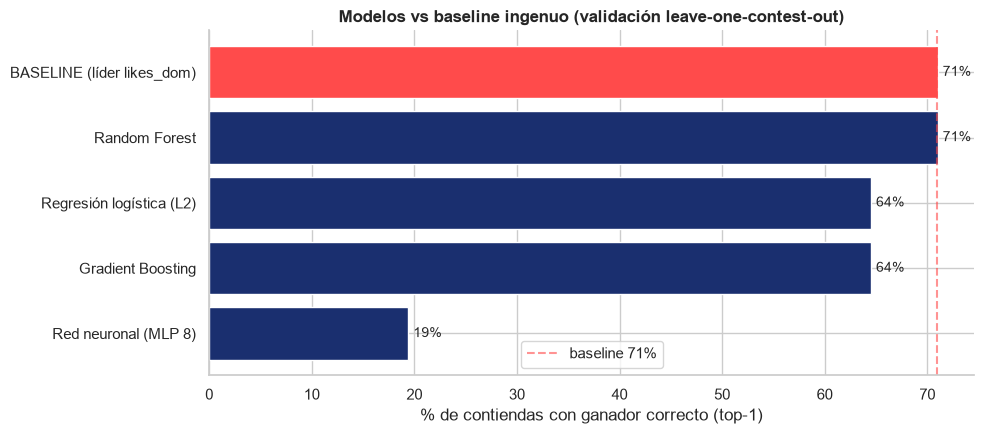

In [7]:
# ---- Gráfica comparativa ----
t = tabla.sort_values("top1_acierto")
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [ROJO if "BASELINE" in m else AZUL_SABANA for m in t["modelo"]]
ax.barh(t["modelo"], t["top1_acierto"], color=colors, edgecolor="white")
ax.axvline(bl*100, color=ROJO, ls="--", alpha=0.6, label=f"baseline {bl:.0%}")
for yi, v in enumerate(t["top1_acierto"]):
    ax.text(v+0.5, yi, f"{v:.0f}%", va="center", fontsize=10)
ax.set_xlabel("% de contiendas con ganador correcto (top-1)")
ax.set_title("Modelos vs baseline ingenuo (validación leave-one-contest-out)", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()


**Cómo leer esto.** Si ningún modelo supera el baseline de forma clara, NO es un fracaso: es
la evidencia honesta de que, con estas features y 31 contiendas, el líder en dominancia ya captura
casi toda la señal disponible. Una diferencia de 1-2 contiendas (~3-6 puntos) está dentro del ruido.


---
## 3 — (Opcional) AutoML con FLAML

Si quieres un AutoML de verdad, FLAML es ligero. **Pero** hay que forzarle la validación agrupada
por contienda; si no, sobreestima. Esta celda es opcional y requiere `pip install flaml`.


In [11]:
# Opcional. Descomenta para usar. Requiere: pip install flaml
try:
    from flaml import AutoML
    automl = AutoML()
    automl.fit(X_train=X, y_train=y, task="classification",
               metric="roc_auc", time_budget=60,
               split_type="group", groups=groups, eval_method="cv", n_splits=5,
               estimator_list=["lgbm", "rf", "lrl2"], verbose=0)
    print("Mejor modelo FLAML:", automl.best_estimator)
    # Evaluamos su top-1 con NUESTRA métrica honesta:
    print("Top-1 (LOGO) del modelo FLAML:", f"{top1_logo(automl.model.estimator, X, y, groups):.1%}")
except ImportError:
    print("FLAML no instalado. `pip install flaml` para habilitarlo. (Opcional)")


FLAML no instalado. `pip install flaml` para habilitarlo. (Opcional)


c:\Users\juansoag\AppData\Local\miniconda3\envs\tesis\Lib\site-packages\flaml\__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


---
## 4 — Diagnóstico: ¿qué pesa y dónde falla?

Entrenamos la regresión logística en todo el set (solo para inspección de coeficientes) y miramos
en qué contiendas el mejor modelo se equivoca — suelen ser las mismas "excepciones" del maestro
(Bogotá, Soledad…).


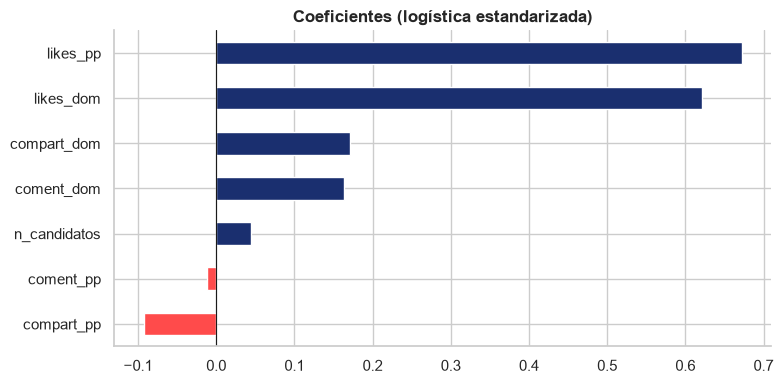

In [12]:
# Coeficientes (dirección e importancia relativa, escala estandarizada)
lr = Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(C=0.5, max_iter=2000))]).fit(X, y)
coefs = pd.Series(lr.named_steps["lr"].coef_[0], index=feat_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
coefs.plot(kind="barh", color=[ROJO if c < 0 else AZUL_SABANA for c in coefs], ax=ax)
ax.set_title("Coeficientes (logística estandarizada)", fontweight="bold")
ax.axvline(0, color="k", lw=0.8); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


In [15]:
# ¿En qué contiendas falla el baseline? (las que el modelo tendría que 'arreglar')
fallos = []
for g in np.unique(groups):
    m = groups == g
    pred_idx = np.argmax(X[m, feat_cols.index("likes_dom")])
    if y[m][pred_idx] != 1:
        sub = base[base["DIVIPOLA"] == g]
        ganador = sub[sub["y"] == 1]["id_candidato"].values
        lider   = sub.iloc[np.argmax(sub["likes_dom"].values)]["id_candidato"]
        fallos.append({"DIVIPOLA": g, "lider_digital": lider,
                       "ganador_real": ganador[0] if len(ganador) else "?",
                       "n_cand": m.sum()})
print(f"Contiendas donde el líder digital NO ganó: {len(fallos)} de {len(np.unique(groups))}")
pd.DataFrame(fallos)


Contiendas donde el líder digital NO ganó: 9 de 31


,DIVIPOLA,lider_digital,ganador_real,n_cand
0,05151,COL-05151-002,COL-05151-003,3
1,08433,COL-08433-001,COL-08433-007,3
2,11001,COL-11001-006,COL-11001-005,9
3,19001,COL-19001-001,COL-19001-010,3
4,23001,COL-23001-006,COL-23001-008,2
5,41001,COL-41001-008,COL-41001-007,6
6,63001,COL-63001-003,COL-63001-013,3
7,66170,COL-66170-005,COL-66170-003,3
8,70001,COL-70001-003,COL-70001-014,3


---
## Notas y siguiente paso

- **Tamaño de muestra.** 31 contiendas es el cuello de botella, no el código. Reporta el acierto
  *con su intervalo* (una proporción sobre 31 tiene una banda ancha) y compáralo siempre con el baseline.
- **Red neuronal.** Si no superó a la logística, es lo esperado: 120 filas / 31 grupos no alcanzan
  para que una red aporte. Una Keras/PyTorch sería peor aún. La logística regularizada es la opción honesta.
- **Validación final real.** La prueba definitiva es la **presidencial 2026**: correr el modelo el
  día antes con datos que no existían al entrenar. Eso es out-of-sample sin discusión.
- **Siguiente:** pasar del binario (¿quién gana?) al **continuo** (¿qué cuota de voto?), que es el
  objetivo de la tesis. Ahí el logit fraccional / beta del maestro es el modelo natural, y la métrica
  deja de ser top-1 para ser error sobre la cuota.
